# Azure OpenAI PTU Sizing & Architecture Guidance Tool — Notebook

This notebook is a front-end over the shared `ptu_core` sizing engine. It estimates baseline PTUs, compares PTU vs PAYGO monthly cost assumptions, and returns an architecture suggestion.

**Important:** This is an internal sizing tool, not the official Azure PTU calculator. Re-verify model throughput, minimum commit, and pricing against current Azure docs before quoting customer-specific numbers.

In [ ]:
import math
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Single source of truth shared with the Streamlit app so the two cannot drift.
from ptu_core import (
    DEFAULTS,
    DEPLOYMENT_TYPES,
    MODEL_PRESETS,
    available_deployment_types,
    available_regions,
    deployment_minimums,
    deployment_hourly_price,
    paygo_rates,
    spillover_supported,
    region_supported,
    calculate,
)

DEFAULTS

{'avg_rpm': 60,
 'avg_input_tokens': 1800,
 'avg_output_tokens': 650,
 'p95_multiplier': 1.8,
 'peak_minutes_fraction': 0.1,
 'cache_rate': 0.2,
 'model_tpm_per_ptu': 3000,
 'output_weight': 4.0,
 'baseline_load_factor': 0.7,
 'safety_buffer': 0.15,
 'min_ptu_commit': 15,
 'ptu_scale_increment': 5,
 'ptu_hourly_price': 1.0,
 'reservation_discount_monthly': 0.64,
 'reservation_discount_yearly': 0.7,
 'paygo_input_per_1m': 2.0,
 'paygo_cached_per_1m': 0.5,
 'paygo_output_per_1m': 8.0,
 'hours_per_month': 730}

In [ ]:
def build_inputs(model_preset="gpt-4.1", deployment_type="Global", region=None, **overrides):
    """Build a calculate() input dict from a model preset + deployment type.

    The preset fills model throughput and output weighting; the deployment type
    selects the minimum PTU commit, scale increment, the indicative hourly $/PTU
    price (Global lowest, Data Zone higher, Regional highest), the Standard/PAYGO
    token rates (Global base, Data Zone/Regional 10% higher), and whether
    automatic spillover is supported (Global/Data Zone only). Pass an optional
    `region` to validate it against the indicative availability list. Any keyword
    override (e.g. avg_rpm=120) wins over the preset/defaults.
    """
    preset = MODEL_PRESETS.get(model_preset, {})
    allowed = available_deployment_types(preset)
    if deployment_type not in allowed:
        raise ValueError(
            f"{model_preset} does not support {deployment_type} provisioned. "
            f"Available: {', '.join(allowed)}."
        )
    if region is not None and not region_supported(model_preset, deployment_type, region):
        offered = ", ".join(available_regions(model_preset, deployment_type)) or "none listed"
        raise ValueError(
            f"{model_preset} {deployment_type} provisioned is not offered in {region} "
            f"(indicative). Available: {offered}."
        )
    min_ptu, increment = deployment_minimums(preset, deployment_type)

    values = DEFAULTS.copy()
    values.update({k: v for k, v in preset.items() if k in DEFAULTS})
    values["min_ptu_commit"] = min_ptu
    values["ptu_scale_increment"] = increment
    values["ptu_hourly_price"] = deployment_hourly_price(deployment_type)
    # Standard/PAYGO token rates vary by deployment type (Global base; Data Zone
    # and Regional are 10% higher), mirroring the differentiated hourly price.
    values["paygo_input_per_1m"], values["paygo_cached_per_1m"], values["paygo_output_per_1m"] = paygo_rates(preset, deployment_type)
    values["spillover_supported"] = spillover_supported(deployment_type)
    values["region"] = region
    values.update(overrides)
    return values

# Show each model preset's supported deployment types, and the per-type hourly
# price plus whether that type supports automatic spillover (Global/Data Zone only).
display(pd.DataFrame(
    [(name, ", ".join(available_deployment_types(p))) for name, p in MODEL_PRESETS.items()],
    columns=["Model preset", "Available deployment types"],
))
pd.DataFrame(
    [(dt, deployment_hourly_price(dt), "Yes" if spillover_supported(dt) else "No",
      len(available_regions("gpt-4.1", dt)))
     for dt in DEPLOYMENT_TYPES],
    columns=["Deployment type", "Indicative hourly $/PTU", "Spillover supported", "Indicative regions (gpt-4.1)"],
)

,Model preset,Available deployment types
0,gpt-5.2,Global
1,gpt-5.1,"Global, Data Zone"
2,gpt-5,"Global, Data Zone, Regional"
3,gpt-5-mini,"Global, Data Zone, Regional"
4,gpt-4.1,"Global, Data Zone, Regional"
5,gpt-4.1-mini,"Global, Data Zone, Regional"
6,gpt-4.1-nano,"Global, Data Zone, Regional"
7,gpt-4o,"Global, Data Zone, Regional"
8,Llama-3.3-70B,Global


,Deployment type,Indicative hourly $/PTU,Spillover supported,Indicative regions (gpt-4.1)
0,Global,1.0,Yes,25
1,Data Zone,1.1,Yes,13
2,Regional,2.0,No,11


## Edit inputs and run

Update any values below for a customer scenario, then run the next cells.


In [3]:
# Choose a model preset and deployment type, then override workload values.
MODEL_PRESET = "gpt-4.1"          # e.g. gpt-5.1, gpt-5-mini, gpt-4.1-mini, gpt-4o, Llama-3.3-70B
DEPLOYMENT_TYPE = "Global"        # Global, Data Zone, or Regional (availability varies by model)

inputs = build_inputs(
    MODEL_PRESET,
    DEPLOYMENT_TYPE,
    avg_rpm=60,
    avg_input_tokens=1800,
    avg_output_tokens=650,
    p95_multiplier=1.8,
)
inputs


{'avg_rpm': 60,
 'avg_input_tokens': 1800,
 'avg_output_tokens': 650,
 'p95_multiplier': 1.8,
 'peak_minutes_fraction': 0.1,
 'cache_rate': 0.2,
 'model_tpm_per_ptu': 3000,
 'output_weight': 4.0,
 'baseline_load_factor': 0.7,
 'safety_buffer': 0.15,
 'min_ptu_commit': 15,
 'ptu_scale_increment': 5,
 'ptu_hourly_price': 1.0,
 'reservation_discount_monthly': 0.64,
 'reservation_discount_yearly': 0.7,
 'paygo_input_per_1m': 2.0,
 'paygo_cached_per_1m': 0.5,
 'paygo_output_per_1m': 8.0,
 'hours_per_month': 730,
 'spillover_supported': True,
 'region': None}

In [4]:
result = calculate(inputs)
summary = pd.DataFrame([
    ('Recommended PTUs', result['recommended_ptu']),
    ('Peak reference PTUs', result['peak_reference_ptu']),
    ('Baseline input-equivalent TPM', result['baseline_tpm']),
    ('P95 input-equivalent TPM', result['p95_tpm']),
    ('PTU monthly', result['ptu_monthly']),
    ('PAYGO monthly', result['paygo_monthly']),
    ('Burst ratio', result['burst_ratio']),
], columns=['Metric', 'Value'])
summary


,Metric,Value
0,Recommended PTUs,120.00
1,Peak reference PTUs,170.00
2,Baseline input-equivalent TPM,305424.00
3,P95 input-equivalent TPM,436320.00
4,PTU monthly,31536.00
5,PAYGO monthly,21707.28
6,Burst ratio,1.80


In [5]:
display(Markdown(f"### {result['architecture']['label']}"))
display(Markdown(result['architecture']['summary']))
display(Markdown(f"**Why:** {result['architecture']['reason']}"))
display(Markdown(f"**Reservation note:** {result['reservation_note']}"))


### PTU-first production baseline

Your workload looks relatively steady and large enough to fill a PTU commitment. PTU is likely a good fit for the primary production layer, then validate on hourly PTU before reservation.

**Why:** Lower peak-to-mean burstiness with a baseline above the model minimum aligns well with PTU economics and predictable throughput.

**Reservation note:** Reservation should be treated as a billing optimization after workload validation, not as the first step and not as capacity by itself.

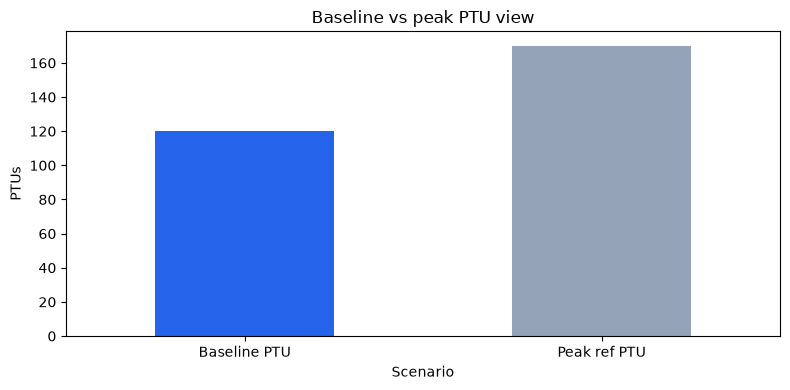

In [6]:
chart_df = pd.DataFrame({
    'Scenario': ['Baseline PTU', 'Peak ref PTU'],
    'PTUs': [result['recommended_ptu'], result['peak_reference_ptu']]
})
ax = chart_df.plot(kind='bar', x='Scenario', y='PTUs', legend=False, figsize=(8, 4), color=['#2563EB', '#94A3B8'])
ax.set_title('Baseline vs peak PTU view')
ax.set_ylabel('PTUs')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Optional widget UI

If `ipywidgets` is available, run the cell below for a lightweight interactive notebook experience.


In [7]:
try:
    import ipywidgets as widgets
    from IPython.display import clear_output

    model_w = widgets.Dropdown(options=list(MODEL_PRESETS.keys()), value='gpt-4.1', description='Model')
    deploy_w = widgets.Dropdown(options=available_deployment_types(MODEL_PRESETS['gpt-4.1']), description='Deploy')
    region_w = widgets.Dropdown(options=available_regions('gpt-4.1', 'Global'), description='Region')
    avg_rpm_w = widgets.FloatText(value=DEFAULTS['avg_rpm'], description='Avg RPM')
    in_w = widgets.FloatText(value=DEFAULTS['avg_input_tokens'], description='In tokens')
    out_w = widgets.FloatText(value=DEFAULTS['avg_output_tokens'], description='Out tokens')
    p95_w = widgets.FloatSlider(value=DEFAULTS['p95_multiplier'], min=1, max=5, step=0.1, description='P95 x')
    cache_w = widgets.FloatSlider(value=DEFAULTS['cache_rate'], min=0, max=0.9, step=0.05, description='Cache')
    btn = widgets.Button(description='Recalculate', button_style='primary')
    out = widgets.Output()

    def _sync_regions():
        # Narrow the region dropdown to the indicative list for the model + type.
        regions = available_regions(model_w.value, deploy_w.value)
        region_w.options = regions
        if regions and region_w.value not in regions:
            region_w.value = regions[0]

    def on_model_change(_=None):
        # Restrict the deployment dropdown to the types the chosen model supports.
        options = available_deployment_types(MODEL_PRESETS[model_w.value])
        deploy_w.options = options
        if deploy_w.value not in options:
            deploy_w.value = options[0]
        _sync_regions()

    def on_deploy_change(_=None):
        _sync_regions()
        refresh()

    def refresh(_=None):
        vals = build_inputs(
            model_w.value,
            deploy_w.value,
            region=region_w.value or None,
            avg_rpm=avg_rpm_w.value,
            avg_input_tokens=in_w.value,
            avg_output_tokens=out_w.value,
            p95_multiplier=p95_w.value,
            cache_rate=cache_w.value,
        )
        r = calculate(vals)
        with out:
            clear_output()
            display(pd.DataFrame([
                ('Model / deployment', f"{model_w.value} · {deploy_w.value}"),
                ('Region (indicative)', region_w.value or '(none listed)'),
                ('Min PTU commit / increment', f"{int(vals['min_ptu_commit'])} / {int(vals['ptu_scale_increment'])}"),
                ('Recommended PTUs', r['recommended_ptu']),
                ('PTU monthly (1-mo reserved)', round(r['ptu_monthly'], 2)),
                ('PAYGO monthly', round(r['paygo_monthly'], 2)),
                ('Architecture', r['architecture']['label']),
            ], columns=['Metric', 'Value']))

    model_w.observe(on_model_change, names='value')
    deploy_w.observe(on_deploy_change, names='value')
    btn.on_click(refresh)
    ui = widgets.VBox([
        widgets.HBox([model_w, deploy_w, region_w]),
        widgets.HBox([avg_rpm_w, in_w, out_w]),
        widgets.HBox([p95_w, cache_w]),
        btn,
        out,
    ])
    display(ui)
    refresh()
except Exception as exc:
    print('ipywidgets UI not available in this environment:', exc)
